# Datasets Combination

Merge all cleaned datasets into one

## A. Overview

List of datasets

- ACL_ICWSM_2018
- CrisisBench *(Combined)*
- CrisisLexT6
- CrisisLexT26
- CrisisMMD_V2
- CrisisNLP_R1
- Ecuador_Earthquake
- Eyewitness Messages
- HumAID
- ISCRAM2013
- SWDM2013

## B. Unified Dataset

### B.1. Merge

In [246]:
from pathlib import Path
# import os
import pandas as pd

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

all_files = [f for f in Path('datasets').rglob('*.csv') if f != Path('datasets/CrisisBench.csv')]
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

Found 10 CSV files in the datasets directory.
 - datasets/SWDM2013.csv
 - datasets/Ecuador_Earthquake_2016.csv
 - datasets/CrisisLexT6.csv
 - datasets/ISCRAM2013.csv
 - datasets/CrisisLexT26.csv
 - datasets/eyewitness_messages.csv
 - datasets/CrisisNLP.csv
 - datasets/ACL_ICWSM_2018.csv
 - datasets/HumAID.csv
 - datasets/CrisisMMD_v2.csv


In [247]:
df['humanitarian_label'].unique()

array([nan, 'Casualties and damage', 'Information Source',
       'Caution and advice', 'Unknown',
       'Donations of money, goods or services', 'injured_or_dead_people',
       'other_useful_information', 'sympathy_and_emotional_support',
       'infrastructure_and_utilities_damage',
       'donation_needs_or_offers_or_volunteering_services',
       'caution_and_advice', 'displaced_people_and_evacuations',
       'missing_trapped_or_found_people', 'not_related_or_irrelevant',
       'Information source', 'People missing, found or seen',
       'rescue_volunteering_or_donation_effort', 'sympathy_and_support',
       'infrastructure_and_utility_damage', 'other_relevant_information',
       'not_humanitarian', 'requests_or_urgent_needs',
       'missing_or_found_people', 'affected_individuals', 'unclassified'],
      dtype=object)

### CrisisBench

The CrisisBench dataset combines
- CrisisLex
- CrisisNLP
- SWDM13
- ISCRAM13
- DRD
- DSM
- CrisisMMD
- AIDR

The author did some cleaning and mapping, so keep their works.

In [248]:
df_cb = pd.read_csv('datasets/CrisisBench.csv')

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_6143/2814787164.py:1: DtypeWarning: Columns (5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cb = pd.read_csv('datasets/CrisisBench.csv')


In [249]:
print(f"df_cb: {len(df_cb)} rows")
print(f"df: {len(df)} rows")

df_cb: 151999 rows
df: 224984 rows


In [250]:
df = df[~df['tweet_id'].isin(df_cb['tweet_id'])]
df = df[~df['tweet_text'].isin(df_cb['tweet_text'])]
df = pd.concat([df, df_cb], ignore_index=True)

df['tweet_id'] = df['tweet_id'].astype(str)

In [251]:
print(f"df: {len(df)} rows")

df: 257216 rows


### B.2. Remove Duplicated

In [252]:
df_dup_id = df[df.duplicated(subset=['tweet_id'], keep=False)]
print(f"Number of duplicate tweet_ids: {len(df_dup_id)}")

df_dup_text = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Number of duplicate tweet_texts: {len(df_dup_text)}")

Number of duplicate tweet_ids: 138
Number of duplicate tweet_texts: 190


In [253]:
set(df_dup_id['tweet_id']).issubset(set(df_dup_text['tweet_id']))

False

In [254]:
df = df.drop_duplicates(subset=['tweet_id']).drop_duplicates(subset=['tweet_text'])
print(f"df: {len(df)} rows")

df: 257092 rows


### B.3. Re-order columns

In [255]:
df = df[['tweet_id', 'tweet_text', 'relevant', 'humanitarian_label', 'dataset',
         'event_type', 'year', 'event_name', 'country', 'url', 'original_relevant_label', 'original_humanitarian_label', 'meta']]

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257092 entries, 0 to 257215
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   tweet_id                     257092 non-null  object 
 1   tweet_text                   257092 non-null  object 
 2   relevant                     257092 non-null  bool   
 3   humanitarian_label           208983 non-null  object 
 4   dataset                      257092 non-null  object 
 5   event_type                   257092 non-null  object 
 6   year                         105096 non-null  float64
 7   event_name                   243291 non-null  object 
 8   country                      8197 non-null    object 
 9   url                          4173 non-null    object 
 10  original_relevant_label      163835 non-null  object 
 11  original_humanitarian_label  204810 non-null  object 
 12  meta                         104577 non-null  object 
dtypes: b

In [257]:
df.head()

,tweet_id,tweet_text,relevant,humanitarian_label,dataset,event_type,year,event_name,country,url,original_relevant_label,original_humanitarian_label,meta
0,999080191633762472432,RT @MichaelHwrdSaul: Mayor Bloomberg calls it ...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
1,999176214043245279029,"RT @xeni: Bloomberg ""our priority is protectin...",True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
2,999184446686026812868,"I think she just signed ""Fuck Chris Christie!""...",False,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
3,999418488332978841649,We are now officially cut off from the rest of...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
4,999930148022756051001,"RT @hum0rdenoche: El huracÃ­Ã§n ""Sandy"" debiÃ­...",False,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN


## C. Humanitarian Label Mapping

In [259]:
print(df['humanitarian_label'].unique())

[nan 'Unknown' 'Information Source' 'injured_or_dead_people'
 'other_useful_information' 'sympathy_and_emotional_support'
 'infrastructure_and_utilities_damage'
 'donation_needs_or_offers_or_volunteering_services' 'caution_and_advice'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'Information source' 'Caution and advice'
 'Casualties and damage' 'Donations of money, goods or services'
 'rescue_volunteering_or_donation_effort' 'sympathy_and_support'
 'infrastructure_and_utility_damage' 'other_relevant_information'
 'not_humanitarian' 'requests_or_urgent_needs' 'missing_or_found_people'
 'requests_or_needs' 'affected_individual' 'donation_and_volunteering'
 'missing_and_found_people' 'response_efforts' 'displaced_and_evacuations']


In [269]:
# map the humanitarian labels to the unified set of labels
df['humanitarian_label'] = df['humanitarian_label'].map(dataset_settings.humanitarian_labels_mapping)
print(df['humanitarian_label'].unique())

[nan 'other_relevant_information' 'injured_or_dead_people'
 'sympathy_and_support' 'infrastructure_and_utility_damage'
 'rescue_volunteering_or_donation_effort'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'not_humanitarian' 'requests_or_needs'
 'affected_individuals']


# D. Review

<Axes: xlabel='dataset'>

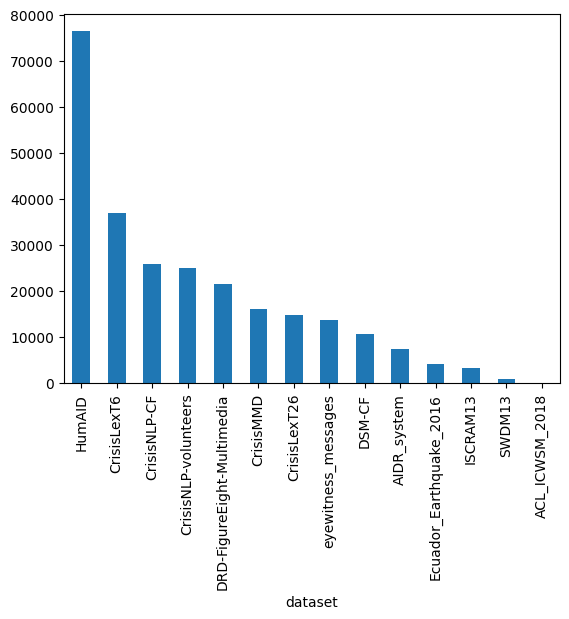

In [262]:
df['dataset'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

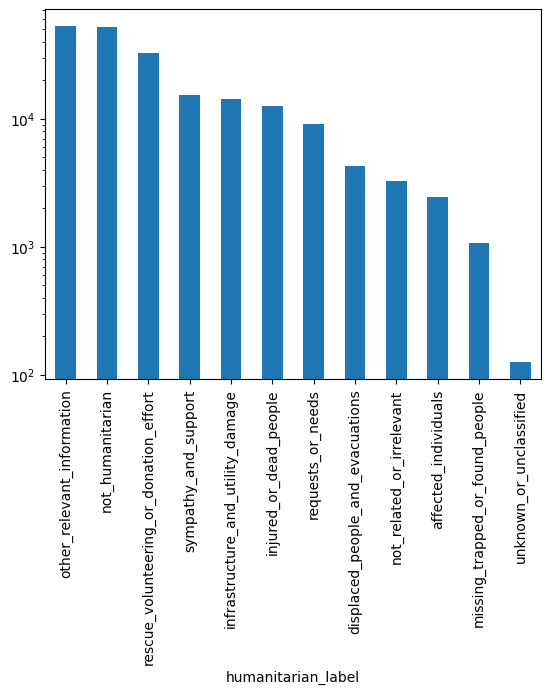

In [263]:
df['humanitarian_label'].value_counts().plot(kind='bar', logy=True)

Text(0.5, 1.0, 'Number of event_name entries for each event_type')

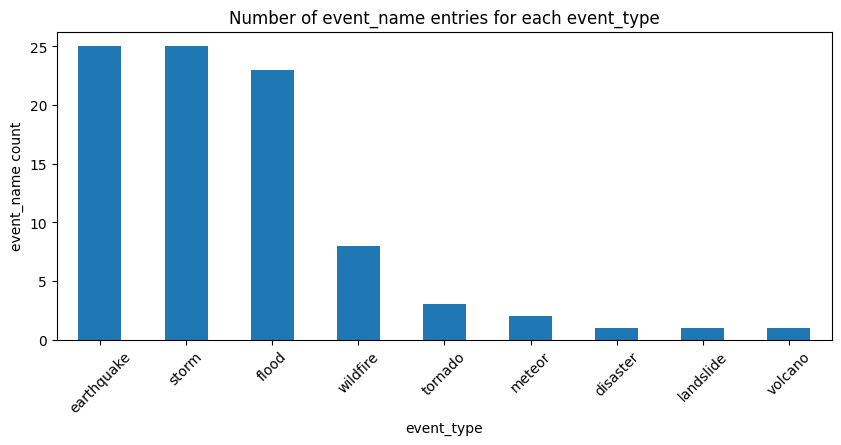

In [264]:
event_name_count_by_type = (
    df.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=45)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type')

In [265]:
event_name_count_by_type.head(10)

event_type
earthquake    25
storm         25
flood         23
wildfire       8
tornado        3
meteor         2
disaster       1
landslide      1
volcano        1
Name: event_name, dtype: int64

<Axes: xlabel='relevant'>

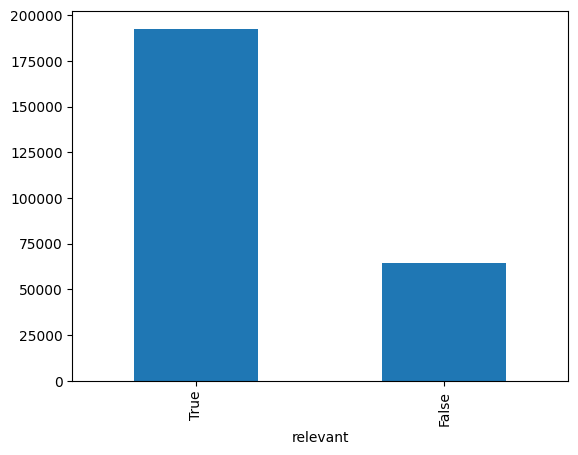

In [266]:
df['relevant'].value_counts().plot(kind='bar')

In [267]:
import csv

df.to_csv('data/unified_dataset.csv', index=False, quoting=csv.QUOTE_ALL)

In [268]:
df.head()

,tweet_id,tweet_text,relevant,humanitarian_label,dataset,event_type,year,event_name,country,url,original_relevant_label,original_humanitarian_label,meta
0,999080191633762472432,RT @MichaelHwrdSaul: Mayor Bloomberg calls it ...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
1,999176214043245279029,"RT @xeni: Bloomberg ""our priority is protectin...",True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
2,999184446686026812868,"I think she just signed ""Fuck Chris Christie!""...",False,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
3,999418488332978841649,We are now officially cut off from the rest of...,True,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
4,999930148022756051001,"RT @hum0rdenoche: El huracÃ­Ã§n ""Sandy"" debiÃ­...",False,NaN,SWDM13,storm,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN,NaN
